## 1. Import Library

In [5]:
# Basic
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Machine Learning Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Preprocessing & Evaluasi
from sklearn.model_selection import (
    RandomizedSearchCV,
    GridSearchCV,
    TimeSeriesSplit
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Bayesian Search (skopt)
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Optuna
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# MLflow
import mlflow
import mlflow.lightgbm
import joblib

## 2. MLFlow Setup

In [6]:
mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment('forecast-harga-komoditas')

<Experiment: artifact_location=('file:///c:/Coding SDT/VS Code/Python/Semester '
 '4/PBL/notebooks/../mlruns/485231392309277735'), creation_time=1777692521144, experiment_id='485231392309277735', last_update_time=1777692521144, lifecycle_stage='active', name='forecast-harga-komoditas', tags={}, trace_location=None, workspace='default'>

## 3. Load Dataset

In [7]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("Shape X_train :", X_train.shape)
print("Shape X_test  :", X_test.shape)
print("Shape y_train :", y_train.shape)
print("Shape y_test  :", y_test.shape)
print("\nFitur yang digunakan:")
print(X_train.columns.tolist())

Shape X_train : (13572, 9)
Shape X_test  : (3709, 9)
Shape y_train : (13572,)
Shape y_test  : (3709,)

Fitur yang digunakan:
['tahun', 'bulan', 'kuartal', 'wilayah_enc', 'komoditas_enc', 'harga_lag1', 'harga_lag2', 'harga_lag3', 'harga_rolling3']


## 4. Preview Data

In [8]:
print("Data X_train:")
display(X_train.head())

print("\nData y_train:")
display(y_train.describe())

Data X_train:


,tahun,bulan,kuartal,wilayah_enc,komoditas_enc,harga_lag1,harga_lag2,harga_lag3,harga_rolling3
0,-1.0,-0.4,-1.0,-1.0,-1.0,0.748019,0.413136,0.451064,0.524350
1,-1.0,-0.2,-1.0,-1.0,-1.0,0.748019,0.756356,0.419149,0.626986
2,-1.0,0.0,0.0,-1.0,-1.0,0.824089,0.756356,0.763830,0.765230
3,-1.0,0.2,0.0,-1.0,-1.0,0.733228,0.832627,0.763830,0.760342
4,-1.0,0.4,0.0,-1.0,-1.0,0.409931,0.741525,0.840426,0.648630



Data y_train:


count     13572.000000
mean      33791.364574
std       33677.157449
min        7500.000000
25%       13500.000000
50%       19400.000000
75%       37200.000000
max      176650.000000
Name: harga, dtype: float64

## 5. Mendefinisikan Model

In [9]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbosity=0
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    ),
}

print("Model yang akan dilatih:")
for name in models:
    print(f"   - {name}")

Model yang akan dilatih:
   - LinearRegression
   - Ridge
   - RandomForest
   - XGBoost
   - LightGBM


## 6. Fungsi Evaluasi

In [10]:
def evaluate_model(y_true, y_pred):
    """Menghitung metrik evaluasi regresi."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE(%)': mape}

print("Fungsi evaluate_model siap digunakan!")

Fungsi evaluate_model siap digunakan!


## 7. Training & Evaluasi Semua Model

In [11]:
results     = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results[name]     = evaluate_model(y_test, y_pred)
    print(f"{name} selesai dilatih")

df_results = pd.DataFrame(results).T.sort_values('RMSE')
df_results = df_results.round({'MAE': 0, 'RMSE': 0, 'R2': 4, 'MAPE(%)': 2})
display(df_results)

LinearRegression selesai dilatih
Ridge selesai dilatih
RandomForest selesai dilatih
XGBoost selesai dilatih


  File "c:\Users\Nicolaus Prima\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Nicolaus Prima\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Nicolaus Prima\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Nicolaus Prima\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


LightGBM selesai dilatih


,MAE,RMSE,R2,MAPE(%)
LightGBM,3048.0,6952.0,0.9610,6.69
RandomForest,3040.0,7001.0,0.9605,6.63
XGBoost,3160.0,7162.0,0.9586,7.05
Ridge,3018.0,7250.0,0.9576,6.70
LinearRegression,3037.0,7257.0,0.9575,6.73


## 8. Pilih Model Terbaik

In [12]:
best_model_name = df_results.index[0]  # RMSE terkecil
best_pred       = predictions[best_model_name]
best_model      = models[best_model_name]

print(f"🏆 Model Terbaik : {best_model_name}")
print(f"   MAE    : {results[best_model_name]['MAE']:,.0f}")
print(f"   RMSE   : {results[best_model_name]['RMSE']:,.0f}")
print(f"   R²     : {results[best_model_name]['R2']:.4f}")
print(f"   MAPE   : {results[best_model_name]['MAPE(%)']:.2f}%")

🏆 Model Terbaik : LightGBM
   MAE    : 3,048
   RMSE   : 6,952
   R²     : 0.9610
   MAPE   : 6.69%


## 9. Grid Search

In [13]:
cv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.05, 0.1],
    'max_depth'     : [5, 7, -1],
    'num_leaves'    : [31, 50],
}

grid_search = GridSearchCV(
    estimator  = lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_grid = param_grid,
    scoring    = 'neg_root_mean_squared_error',
    cv         = cv,
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train, y_train)

grid_pred    = grid_search.best_estimator_.predict(X_test)
grid_metrics = evaluate_model(y_test, grid_pred)

print('\nGrid Search selesai!')
print(f'   Best Params : {grid_search.best_params_}')
print(f'   CV RMSE     : {-grid_search.best_score_:,.0f}')
print(f'   Test RMSE   : {grid_metrics["RMSE"]:,.0f} | R²: {grid_metrics["R2"]:.4f} | MAPE: {grid_metrics["MAPE(%)"]:,.2f}%')


Fitting 5 folds for each of 36 candidates, totalling 180 fits

Grid Search selesai!
   Best Params : {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}
   CV RMSE     : 5,533
   Test RMSE   : 6,902 | R²: 0.9616 | MAPE: 6.65%


## 10. Randomized Search

In [14]:
param_dist = {
    'n_estimators'      : [100, 200, 300, 500],
    'learning_rate'     : [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth'         : [3, 5, 7, 9, -1],
    'num_leaves'        : [20, 31, 50, 70, 100],
    'min_child_samples' : [10, 20, 30, 50],
    'subsample'         : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree'  : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'         : [0, 0.01, 0.1, 0.5],
    'reg_lambda'        : [0, 0.01, 0.1, 0.5, 1.0],
}

random_search = RandomizedSearchCV(
    estimator           = lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_distributions = param_dist,
    n_iter              = 50,
    scoring             = 'neg_root_mean_squared_error',
    cv                  = cv,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)
random_search.fit(X_train, y_train)

random_pred    = random_search.best_estimator_.predict(X_test)
random_metrics = evaluate_model(y_test, random_pred)

print('\nRandomized Search selesai!')
print(f'   Best Params : {random_search.best_params_}')
print(f'   CV RMSE     : {-random_search.best_score_:,.0f}')
print(f'   Test RMSE   : {random_metrics["RMSE"]:,.0f} | R²: {random_metrics["R2"]:.4f} | MAPE: {random_metrics["MAPE(%)"]:,.2f}%')


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Randomized Search selesai!
   Best Params : {'subsample': 0.6, 'reg_lambda': 0, 'reg_alpha': 0.01, 'num_leaves': 50, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 9, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
   CV RMSE     : 5,496
   Test RMSE   : 6,961 | R²: 0.9609 | MAPE: 6.78%


## 11. Bayesian Search

In [15]:
bayes_space = {
    'n_estimators'      : Integer(100, 500),
    'learning_rate'     : Real(0.01, 0.2, prior='log-uniform'),
    'max_depth'         : Integer(3, 10),
    'num_leaves'        : Integer(20, 100),
    'min_child_samples' : Integer(10, 50),
    'subsample'         : Real(0.6, 1.0),
    'colsample_bytree'  : Real(0.6, 1.0),
    'reg_alpha'         : Real(0.0, 0.5),
    'reg_lambda'        : Real(0.0, 1.0),
}

bayes_search = BayesSearchCV(
    estimator  = lgb.LGBMRegressor(random_state=42, verbose=-1),
    search_spaces = bayes_space,
    n_iter     = 50,
    scoring    = 'neg_root_mean_squared_error',
    cv         = cv,
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1
)
bayes_search.fit(X_train, y_train)

bayes_pred    = bayes_search.best_estimator_.predict(X_test)
bayes_metrics = evaluate_model(y_test, bayes_pred)

print("\nBayesian Search selesai!")
print(f"   Best Params : {dict(bayes_search.best_params_)}")
print(f"   CV RMSE     : {-bayes_search.best_score_:,.0f}")
print(f"   Test RMSE   : {bayes_metrics['RMSE']:,.0f} | R²: {bayes_metrics['R2']:.4f} | MAPE: {bayes_metrics['MAPE(%)']:.2f}%")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

## 12. Optuna

In [16]:
def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 50),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 0.0, 0.5),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state'      : 42,
        'verbose'           : -1,
    }

    model  = lgb.LGBMRegressor(**params)
    scores = []
    for train_idx, val_idx in cv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr)
        pred  = model.predict(X_val)
        rmse  = np.sqrt(mean_squared_error(y_val, pred))
        scores.append(rmse)
    return np.mean(scores)

study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

optuna_model = lgb.LGBMRegressor(**study.best_params, random_state=42, verbose=-1)
optuna_model.fit(X_train, y_train)
optuna_pred    = optuna_model.predict(X_test)
optuna_metrics = evaluate_model(y_test, optuna_pred)

print('\nOptuna selesai!')
print(f'   Best Params : {study.best_params}')
print(f'   CV RMSE     : {study.best_value:,.0f}')
print(f'   Test RMSE   : {optuna_metrics["RMSE"]:,.0f} | R²: {optuna_metrics["R2"]:.4f} | MAPE: {optuna_metrics["MAPE(%)"]:,.2f}%')


  0%|          | 0/50 [00:00<?, ?it/s]


Optuna selesai!
   Best Params : {'n_estimators': 194, 'learning_rate': 0.10217295789492963, 'max_depth': 10, 'num_leaves': 27, 'min_child_samples': 14, 'subsample': 0.8162677862607134, 'colsample_bytree': 0.871293590081442, 'reg_alpha': 0.25015068717224465, 'reg_lambda': 0.08575118717956925}
   CV RMSE     : 5,485
   Test RMSE   : 7,213 | R²: 0.9580 | MAPE: 7.08%


## 13. Rekap Semua Hasil Tuning

In [17]:
tuning_results = {
    'LightGBM (Default)'  : results['LightGBM'],
    'Grid Search'         : grid_metrics,
    'Randomized Search'   : random_metrics,
    'Bayesian Search'     : bayes_metrics,
    'Optuna'              : optuna_metrics,
}

df_tuning = pd.DataFrame(tuning_results).T
df_tuning = df_tuning.round({'MAE': 0, 'RMSE': 0, 'R2': 4, 'MAPE(%)': 2})
df_tuning = df_tuning.sort_values('RMSE')

print("📊 Rekap Hasil Semua Metode Tuning:")
display(df_tuning)

best_tuning_name = df_tuning.index[0]
print(f"\nMetode terbaik: {best_tuning_name}")

📊 Rekap Hasil Semua Metode Tuning:


,MAE,RMSE,R2,MAPE(%)
Grid Search,3019.0,6902.0,0.9616,6.65
LightGBM (Default),3048.0,6952.0,0.9610,6.69
Randomized Search,3063.0,6961.0,0.9609,6.78
Bayesian Search,3116.0,7011.0,0.9604,6.93
Optuna,3186.0,7213.0,0.9580,7.08



Metode terbaik: Grid Search


## 14. Set Final Model

In [18]:
best_tuning_name = df_tuning.index[0]

tuning_model_map = {
    'LightGBM (Default)' : models['LightGBM'],
    'Grid Search'        : grid_search.best_estimator_,
    'Randomized Search'  : random_search.best_estimator_,
    'Bayesian Search'    : bayes_search.best_estimator_,
    'Optuna'             : optuna_model,
}

tuning_pred_map = {
    'LightGBM (Default)' : predictions['LightGBM'],
    'Grid Search'        : grid_pred,
    'Randomized Search'  : random_pred,
    'Bayesian Search'    : bayes_pred,
    'Optuna'             : optuna_pred,
}

final_model = tuning_model_map[best_tuning_name]
final_pred  = tuning_pred_map[best_tuning_name]
final_metrics = tuning_results[best_tuning_name]

print(f'Final model: {best_tuning_name}')
print(f'   MAE   : {final_metrics["MAE"]:,.0f}')
print(f'   RMSE  : {final_metrics["RMSE"]:,.0f}')
print(f'   R²    : {final_metrics["R2"]:.4f}')
print(f'   MAPE  : {final_metrics["MAPE(%)"]:,.2f}%')


Final model: Grid Search
   MAE   : 3,019
   RMSE  : 6,902
   R²    : 0.9616
   MAPE  : 6.65%


## 15. Plot Perbandingan Semua Metode Tuning

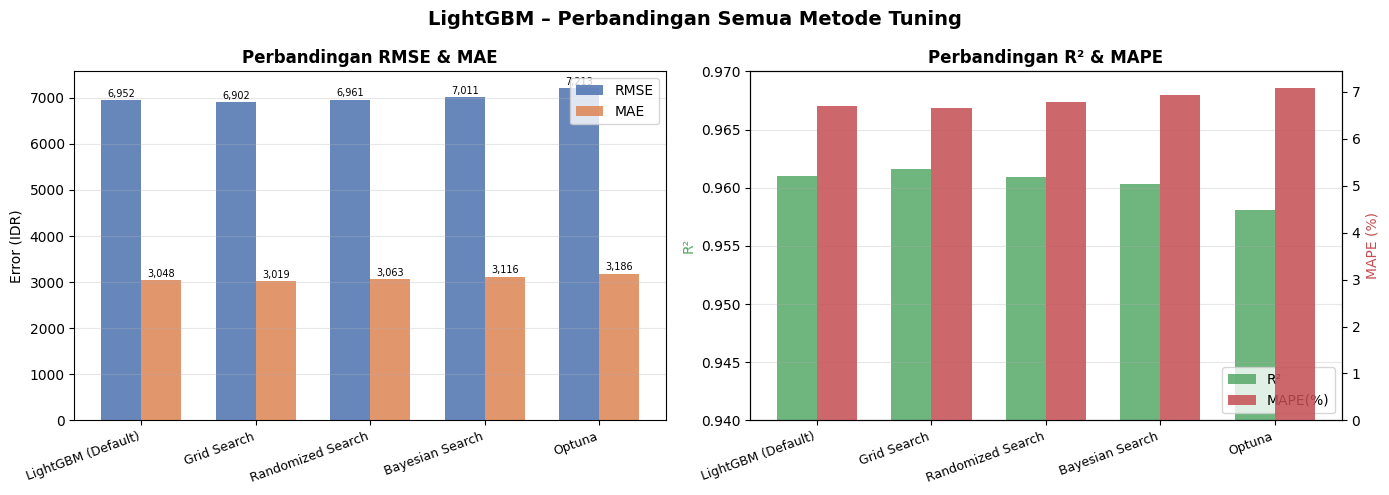

In [19]:
tuning_results = {
    'LightGBM (Default)' : results['LightGBM'],
    'Grid Search'        : grid_metrics,
    'Randomized Search'  : random_metrics,
    'Bayesian Search'    : bayes_metrics,
    'Optuna'             : optuna_metrics,
}

names     = list(tuning_results.keys())
rmse_vals = [tuning_results[m]['RMSE'] for m in names]
mae_vals  = [tuning_results[m]['MAE']  for m in names]
r2_vals   = [tuning_results[m]['R2']   for m in names]
mape_vals = [tuning_results[m]['MAPE(%)'] for m in names]
x     = np.arange(len(names))
bar_w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- RMSE & MAE ---
b1 = axes[0].bar(x - bar_w/2, rmse_vals, bar_w, label='RMSE', color='#4C72B0', alpha=0.85)
b2 = axes[0].bar(x + bar_w/2, mae_vals,  bar_w, label='MAE',  color='#DD8452', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[0].set_title('Perbandingan RMSE & MAE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Error (IDR)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=7)

# --- R² & MAPE ---
ax2 = axes[1].twinx()
b3 = axes[1].bar(x - bar_w/2, r2_vals,   bar_w, label='R²',     color='#55A868', alpha=0.85)
b4 = ax2.bar    (x + bar_w/2, mape_vals, bar_w, label='MAPE(%)', color='#C44E52', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[1].set_title('Perbandingan R² & MAPE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R²', color='#55A868')
ax2.set_ylabel('MAPE (%)', color='#C44E52')
axes[1].set_ylim(0.94, 0.97)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='lower right')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('LightGBM – Perbandingan Semua Metode Tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Tabel Rekap Semua Metode

In [20]:
df_tuning = pd.DataFrame(tuning_results).T
df_tuning = df_tuning.round({'MAE': 0, 'RMSE': 0, 'R2': 4, 'MAPE(%)': 2})
df_tuning = df_tuning.sort_values('RMSE')

# Highlight baris terbaik
def highlight_best(s):
    is_best = s == s.min() if s.name in ['MAE', 'RMSE', 'MAPE(%)'] else s == s.max()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_best]

print("Rekap Hasil Semua Metode Tuning:")
df_tuning.style.apply(highlight_best)

Rekap Hasil Semua Metode Tuning:


,MAE,RMSE,R2,MAPE(%)
Grid Search,3019.000000,6902.000000,0.961600,6.650000
LightGBM (Default),3048.000000,6952.000000,0.961000,6.690000
Randomized Search,3063.000000,6961.000000,0.960900,6.780000
Bayesian Search,3116.000000,7011.000000,0.960400,6.930000
Optuna,3186.000000,7213.000000,0.958000,7.080000


## 17. Plot Actual vs Predicted

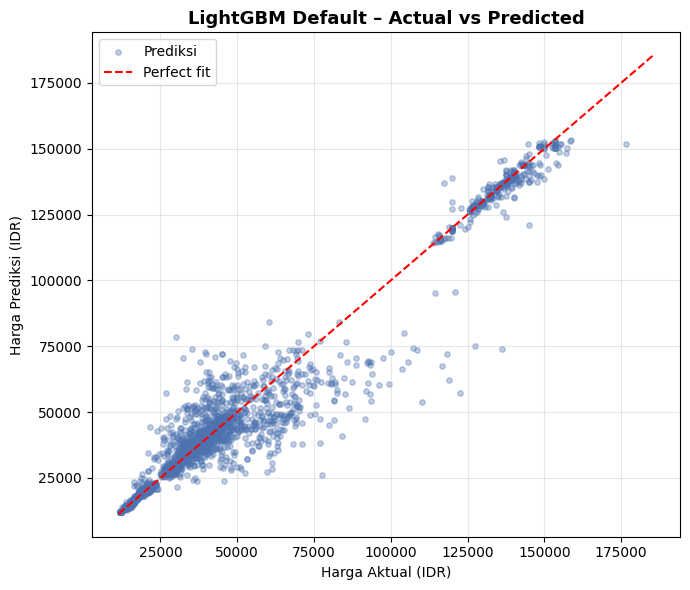

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, final_pred, alpha=0.35, s=15, color='#4C72B0', label='Prediksi')
lims = [min(y_test.min(), final_pred.min()) * 0.95,
        max(y_test.max(), final_pred.max()) * 1.05]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Harga Aktual (IDR)')
ax.set_ylabel('Harga Prediksi (IDR)')
ax.set_title('LightGBM Default – Actual vs Predicted', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Plot Distribusi Residual

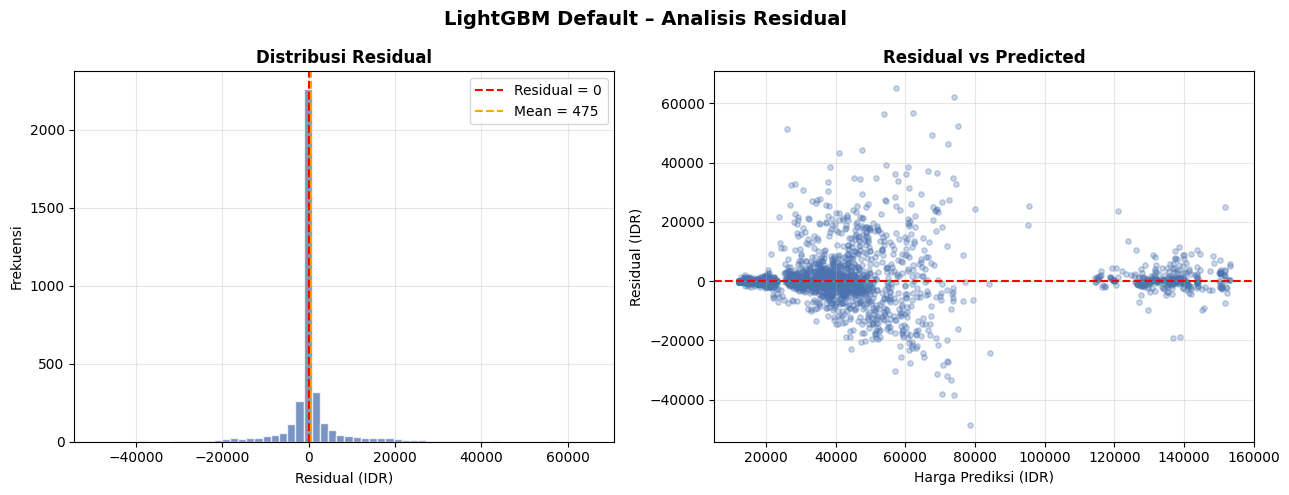

In [22]:
residuals = y_test.values - final_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Histogram residual ---
axes[0].hist(residuals, bins=60, color='#4C72B0', alpha=0.75, edgecolor='white')
axes[0].axvline(0, color='red', lw=1.5, linestyle='--', label='Residual = 0')
axes[0].axvline(np.mean(residuals), color='orange', lw=1.5, linestyle='--',
                label=f'Mean = {np.mean(residuals):,.0f}')
axes[0].set_xlabel('Residual (IDR)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Residual', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Residual vs Predicted (scatter) ---
axes[1].scatter(final_pred, residuals, alpha=0.3, s=15, color='#4C72B0')
axes[1].axhline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Harga Prediksi (IDR)')
axes[1].set_ylabel('Residual (IDR)')
axes[1].set_title('Residual vs Predicted', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('LightGBM Default – Analisis Residual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 19. Plot Feature Importance

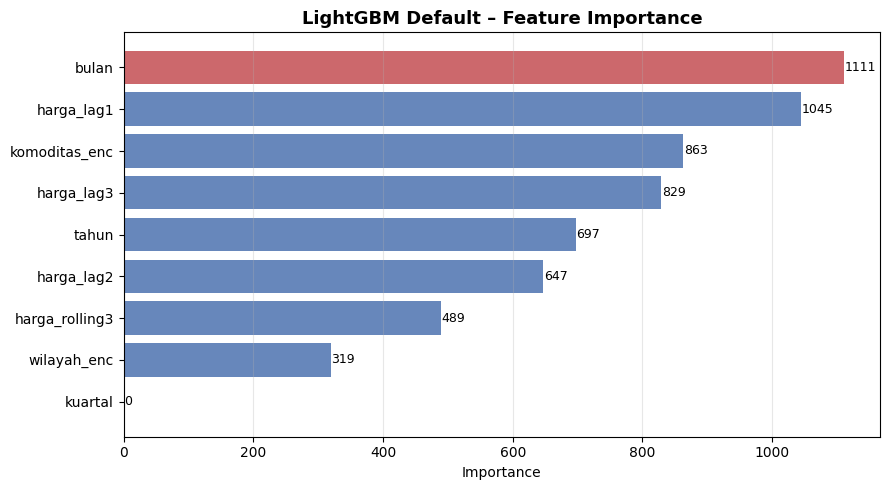

In [23]:
feature_imp = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns
).sort_values()

colors_fi = ['#4C72B0' if v < feature_imp.max() else '#C44E52' for v in feature_imp]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feature_imp.index, feature_imp.values, color=colors_fi, alpha=0.85)
ax.set_title('LightGBM Default – Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
for bar, val in zip(bars, feature_imp.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 20. Plot Error Distribution per Kuartil Harga

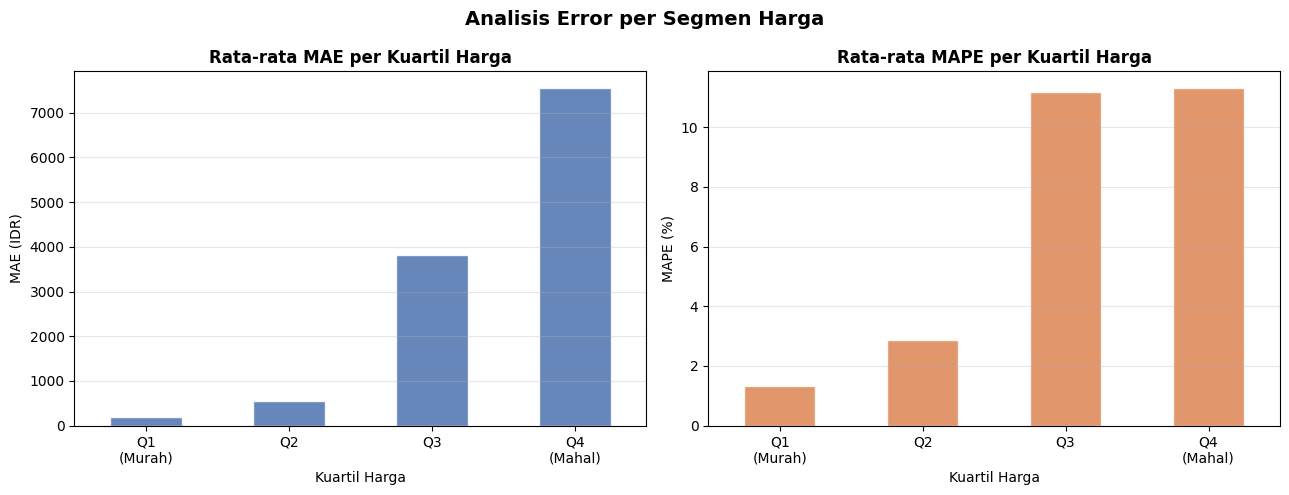

In [24]:
df_eval = pd.DataFrame({
    'harga_aktual'  : y_test.values,
    'harga_prediksi': final_pred,
    'error_abs'     : np.abs(y_test.values - final_pred),
    'mape_per_row'  : np.abs((y_test.values - final_pred) / y_test.values) * 100
})

df_eval['kuartil'] = pd.qcut(df_eval['harga_aktual'], q=4,
                              labels=['Q1\n(Murah)', 'Q2', 'Q3', 'Q4\n(Mahal)'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- MAE per kuartil ---
df_eval.groupby('kuartil')['error_abs'].mean().plot(
    kind='bar', ax=axes[0], color='#4C72B0', alpha=0.85, edgecolor='white')
axes[0].set_title('Rata-rata MAE per Kuartil Harga', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kuartil Harga')
axes[0].set_ylabel('MAE (IDR)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# --- MAPE per kuartil ---
df_eval.groupby('kuartil')['mape_per_row'].mean().plot(
    kind='bar', ax=axes[1], color='#DD8452', alpha=0.85, edgecolor='white')
axes[1].set_title('Rata-rata MAPE per Kuartil Harga', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kuartil Harga')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Analisis Error per Segmen Harga', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 21. Learning Curve

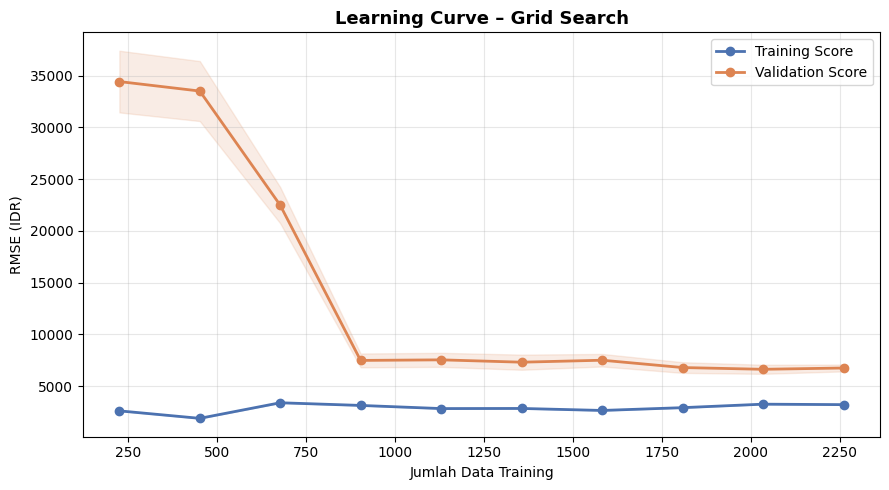


📊 Training RMSE akhir  : 3,206
📊 Validation RMSE akhir: 6,747
📊 Gap                  : 3,541
Gap cukup besar → indikasi overfitting


In [25]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator   = final_model,
    X           = X_train,
    y           = y_train,
    train_sizes = np.linspace(0.1, 1.0, 10),
    scoring     = 'neg_root_mean_squared_error',
    cv          = TimeSeriesSplit(n_splits=5),
    n_jobs      = -1,
    verbose     = 0
)

train_scores_mean = -train_scores.mean(axis=1)
train_scores_std  =  train_scores.std(axis=1)
val_scores_mean   = -val_scores.mean(axis=1)
val_scores_std    =  val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores_mean, 'o-', color='#4C72B0', lw=2, label='Training Score')
ax.plot(train_sizes, val_scores_mean,   'o-', color='#DD8452', lw=2, label='Validation Score')
ax.fill_between(train_sizes,
                train_scores_mean - train_scores_std,
                train_scores_mean + train_scores_std,
                alpha=0.15, color='#4C72B0')
ax.fill_between(train_sizes,
                val_scores_mean - val_scores_std,
                val_scores_mean + val_scores_std,
                alpha=0.15, color='#DD8452')
ax.set_title(f'Learning Curve – {best_tuning_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Data Training')
ax.set_ylabel('RMSE (IDR)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gap = abs(train_scores_mean[-1] - val_scores_mean[-1])
print(f'\n📊 Training RMSE akhir  : {train_scores_mean[-1]:,.0f}')
print(f'📊 Validation RMSE akhir: {val_scores_mean[-1]:,.0f}')
print(f'📊 Gap                  : {gap:,.0f}')
if gap > 3000:
    print('Gap cukup besar → indikasi overfitting')
elif train_scores_mean[-1] > 5000:
    print('Training RMSE masih tinggi → indikasi underfitting')
else:
    print('Model fit dengan baik')


## 22. MLFlow Logging and Save Model

In [27]:
with mlflow.start_run(run_name=best_tuning_name):
    # Log parameter model
    mlflow.log_param('model_type', 'LightGBM')
    mlflow.log_param('tuning_method', best_tuning_name)
    if hasattr(final_model, 'get_params'):
        mlflow.log_params(final_model.get_params())

    # Log metrik
    mlflow.log_metric('MAE',    final_metrics['MAE'])
    mlflow.log_metric('RMSE',   final_metrics['RMSE'])
    mlflow.log_metric('R2',     final_metrics['R2'])
    mlflow.log_metric('MAPE',   final_metrics['MAPE(%)'])

    # Log model ke MLflow
    mlflow.lightgbm.log_model(final_model, artifact_path='model')

        # Simpan ke models/ (untuk arsip/MLflow)
    joblib.dump(final_model, '../models/lgbm_final.joblib')

    # Simpan ke api/models/ (untuk serving)
    joblib.dump(final_model, '../api/models/lgbm_final.joblib')

    run_id = mlflow.active_run().info.run_id
    print(f'MLflow run selesai!')
    print(f'   Run ID      : {run_id}')
    print(f'   Model       : {best_tuning_name}')
    print(f'   MAE         : {final_metrics["MAE"]:,.0f}')
    print(f'   RMSE        : {final_metrics["RMSE"]:,.0f}')
    print(f'   R²          : {final_metrics["R2"]:.4f}')
    print(f'   MAPE        : {final_metrics["MAPE(%)"]:,.2f}%')
    print(f'\nModel disimpan ke: ../models/lgbm_final.joblib')
    print(f'Lihat MLflow UI  : jalankan `mlflow ui` di terminal dari folder root')


2026/05/02 11:26:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/02 11:26:00 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run selesai!
   Run ID      : 0514eb2fcfd040158dc5748104573bc5
   Model       : Grid Search
   MAE         : 3,019
   RMSE        : 6,902
   R²          : 0.9616
   MAPE        : 6.65%

Model disimpan ke: ../models/lgbm_final.joblib
Lihat MLflow UI  : jalankan `mlflow ui` di terminal dari folder root
